In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:

d = pd.read_csv("Sample - Superstore.csv",encoding="cp1252")
d.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
d.shape

In [ ]:
d.describe()

In [6]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
d.isnull().sum()

In [9]:
d.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [11]:
for col in d.columns:
    print(f"\nColumn: {col}")
    print(d[col].unique())



Column: Row ID
[   1    2    3 ... 9992 9993 9994]

Column: Order ID
['CA-2016-152156' 'CA-2016-138688' 'US-2015-108966' ... 'CA-2014-110422'
 'CA-2017-121258' 'CA-2017-119914']

Column: Order Date
['11/8/2016' '6/12/2016' '10/11/2015' ... '6/3/2016' '4/12/2015'
 '1/21/2014']

Column: Ship Date
['11/11/2016' '6/16/2016' '10/18/2015' ... '5/23/2015' '1/23/2014'
 '3/3/2017']

Column: Ship Mode
['Second Class' 'Standard Class' 'First Class' 'Same Day']

Column: Customer ID
['CG-12520' 'DV-13045' 'SO-20335' 'BH-11710' 'AA-10480' 'IM-15070'
 'HP-14815' 'PK-19075' 'AG-10270' 'ZD-21925' 'KB-16585' 'SF-20065'
 'EB-13870' 'EH-13945' 'TB-21520' 'MA-17560' 'GH-14485' 'SN-20710'
 'LC-16930' 'RA-19885' 'ES-14080' 'ON-18715' 'PO-18865' 'LH-16900'
 'DP-13000' 'JM-15265' 'TB-21055' 'KM-16720' 'PS-18970' 'BS-11590'
 'KD-16270' 'HM-14980' 'JE-15745' 'KB-16600' 'SC-20770' 'DN-13690'
 'JC-16105' 'CS-12400' 'PG-18895' 'GM-14455' 'JS-15685' 'KB-16315'
 'RB-19705' 'PN-18775' 'KD-16345' 'ER-13855' 'RB-19465'

In [12]:
# Regex for special characters (excluding letters, numbers, and spaces)
pattern = r'[^a-zA-Z0-9\s]'

for col in d.columns:
    if d[col].dtype == 'object':  # Only check text columns
        special_rows = d[d[col].astype(str).str.contains(pattern, regex=True, na=False)]

        if not special_rows.empty:
            print(f"\nColumn: {col}")
            print(special_rows[[col]])


Column: Order ID
            Order ID
0     CA-2016-152156
1     CA-2016-152156
2     CA-2016-138688
3     US-2015-108966
4     US-2015-108966
...              ...
9989  CA-2014-110422
9990  CA-2017-121258
9991  CA-2017-121258
9992  CA-2017-121258
9993  CA-2017-119914

[9994 rows x 1 columns]

Column: Order Date
      Order Date
0      11/8/2016
1      11/8/2016
2      6/12/2016
3     10/11/2015
4     10/11/2015
...          ...
9989   1/21/2014
9990   2/26/2017
9991   2/26/2017
9992   2/26/2017
9993    5/4/2017

[9994 rows x 1 columns]

Column: Ship Date
       Ship Date
0     11/11/2016
1     11/11/2016
2      6/16/2016
3     10/18/2015
4     10/18/2015
...          ...
9989   1/23/2014
9990    3/3/2017
9991    3/3/2017
9992    3/3/2017
9993    5/9/2017

[9994 rows x 1 columns]

Column: Customer ID
     Customer ID
0       CG-12520
1       CG-12520
2       DV-13045
3       SO-20335
4       SO-20335
...          ...
9989    TB-21400
9990    DB-13060
9991    DB-13060
9992    DB-13060


In [14]:
# finding the duplicate rows or data 
d.duplicated().sum()

np.int64(0)

In [ ]:
# Finding if any unwanted special character is present in the dataset or not...........
for col in d.select_dtypes(include='object').columns:
    blank_count = (d[col].astype(str).str.strip() == "").sum()

    if blank_count > 0:
        print(f"{col}: {blank_count} blank values")

In [16]:
for col in d.select_dtypes(include='object').columns:
    blanks = d[d[col].astype(str).str.strip() == ""]

    if not blanks.empty:
        print(f"\nColumn: {col}")
        print(blanks[[col]])

In [17]:
import re

pattern = r'[^a-zA-Z0-9\s]'

for col in d.select_dtypes(include='object').columns:
    count = d[col].astype(str).str.contains(pattern, regex=True, na=False).sum()

    if count > 0:
        print(f"{col}: {count} values contain special characters")

Order ID: 9994 values contain special characters
Order Date: 9994 values contain special characters
Ship Date: 9994 values contain special characters
Customer ID: 9994 values contain special characters
Customer Name: 242 values contain special characters
Product ID: 9994 values contain special characters
Product Name: 4695 values contain special characters


In [19]:
import re

for col in d.select_dtypes(include='object').columns:

    mixed = d[col].dropna().astype(str)

    mixed = mixed[
        mixed.str.contains(r'\d', regex=True) &      # contains a digit
        mixed.str.contains(r'[A-Za-z$₹%/,+()-]', regex=True)  # contains text/symbols
    ]

    if not mixed.empty:
        print(f"\nColumn: {col}")
        print(mixed.unique()[:10])   # show first 20 unique values


Column: Order ID
['CA-2016-152156' 'CA-2016-138688' 'US-2015-108966' 'CA-2014-115812'
 'CA-2017-114412' 'CA-2016-161389' 'US-2015-118983' 'CA-2014-105893'
 'CA-2014-167164' 'CA-2014-143336']

Column: Order Date
['11/8/2016' '6/12/2016' '10/11/2015' '6/9/2014' '4/15/2017' '12/5/2016'
 '11/22/2015' '11/11/2014' '5/13/2014' '8/27/2014']

Column: Ship Date
['11/11/2016' '6/16/2016' '10/18/2015' '6/14/2014' '4/20/2017'
 '12/10/2016' '11/26/2015' '11/18/2014' '5/15/2014' '9/1/2014']

Column: Customer ID
['CG-12520' 'DV-13045' 'SO-20335' 'BH-11710' 'AA-10480' 'IM-15070'
 'HP-14815' 'PK-19075' 'AG-10270' 'ZD-21925']

Column: Product ID
['FUR-BO-10001798' 'FUR-CH-10000454' 'OFF-LA-10000240' 'FUR-TA-10000577'
 'OFF-ST-10000760' 'FUR-FU-10001487' 'OFF-AR-10002833' 'TEC-PH-10002275'
 'OFF-BI-10003910' 'OFF-AP-10002892']

Column: Product Name
['Bretford CR4500 Series Slim Rectangular Table' 'Newell 322'
 'Mitel 5320 IP Phone VoIP phone' 'Belkin F5C206VTEL 6 Outlet Surge'
 'Konftel 250 Conference\x

C:\Users\user\AppData\Local\Temp\ipykernel_5052\3947723981.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(d[col].dropna(), vert=True)


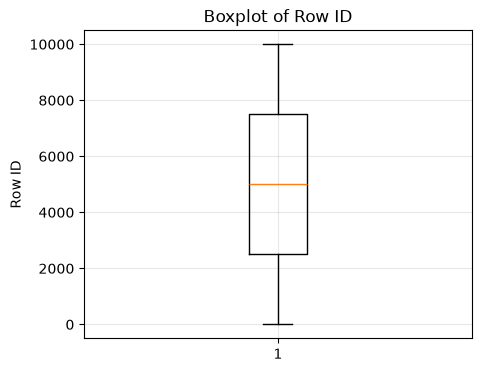

C:\Users\user\AppData\Local\Temp\ipykernel_5052\3947723981.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(d[col].dropna(), vert=True)


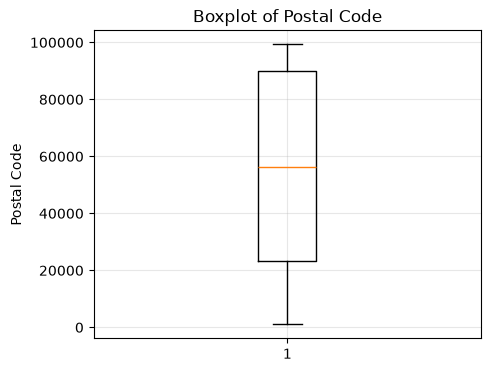

C:\Users\user\AppData\Local\Temp\ipykernel_5052\3947723981.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(d[col].dropna(), vert=True)


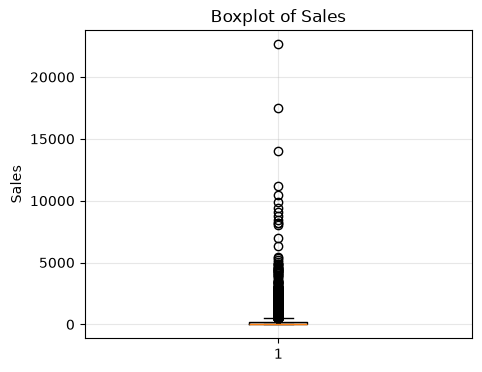

C:\Users\user\AppData\Local\Temp\ipykernel_5052\3947723981.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(d[col].dropna(), vert=True)


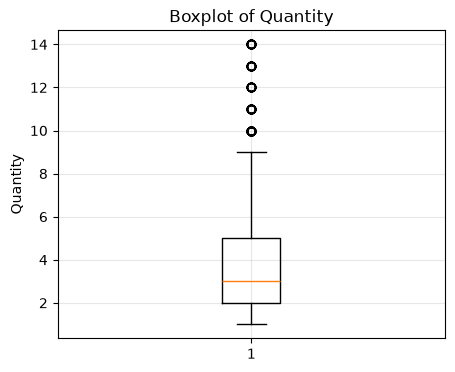

C:\Users\user\AppData\Local\Temp\ipykernel_5052\3947723981.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(d[col].dropna(), vert=True)


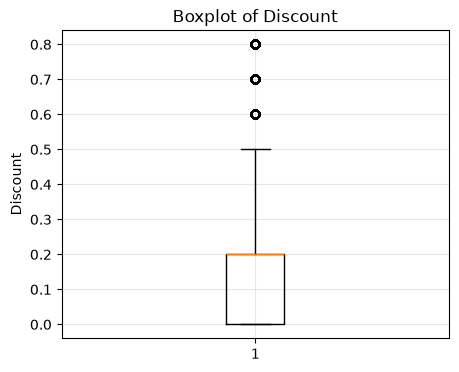

C:\Users\user\AppData\Local\Temp\ipykernel_5052\3947723981.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(d[col].dropna(), vert=True)


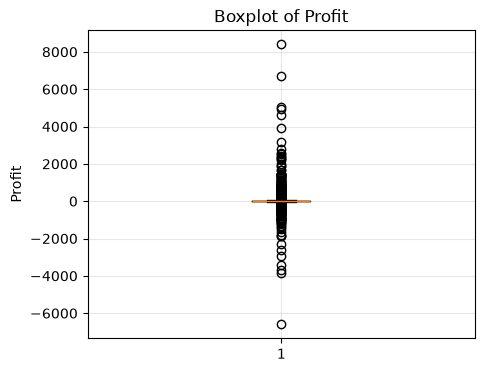

In [21]:
# We need to detect the outliers 
# we will using the histograms and other plottings to find the outlier using visualization by matplotlib 
numeric_cols = d.select_dtypes(include='number').columns
for col in numeric_cols:
    plt.figure(figsize=(5,4))
    plt.boxplot(d[col].dropna(), vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.grid(alpha=0.3)
    plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_5052\1555213245.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(d[col].dropna(), vert=True)


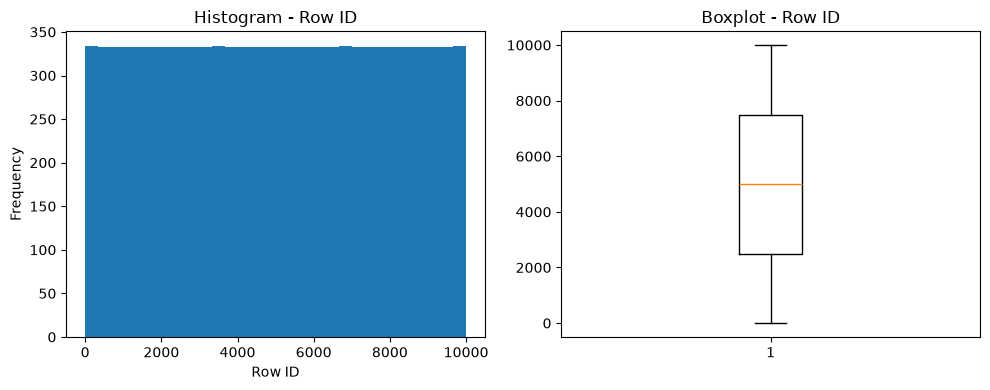

C:\Users\user\AppData\Local\Temp\ipykernel_5052\1555213245.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(d[col].dropna(), vert=True)


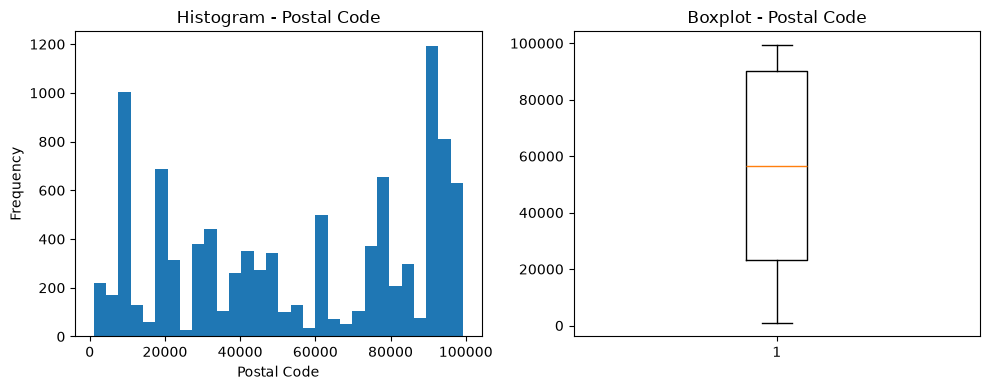

C:\Users\user\AppData\Local\Temp\ipykernel_5052\1555213245.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(d[col].dropna(), vert=True)


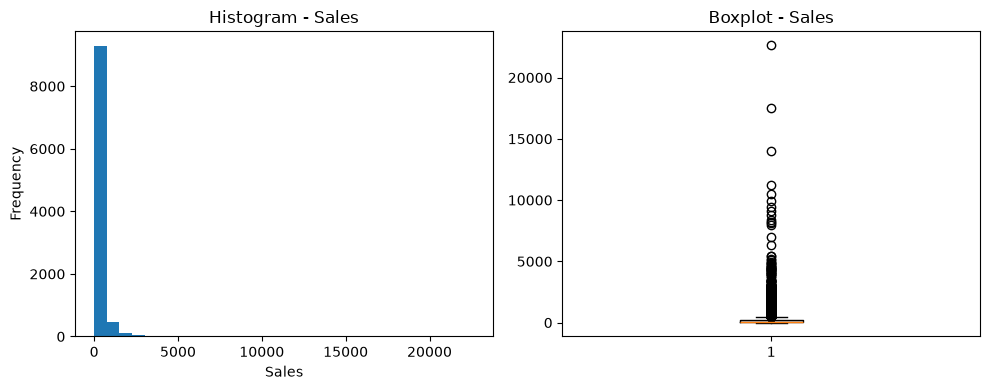

C:\Users\user\AppData\Local\Temp\ipykernel_5052\1555213245.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(d[col].dropna(), vert=True)


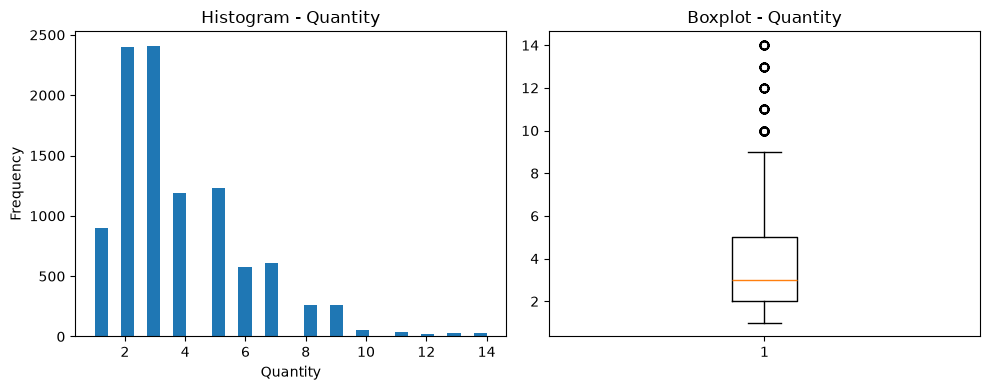

C:\Users\user\AppData\Local\Temp\ipykernel_5052\1555213245.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(d[col].dropna(), vert=True)


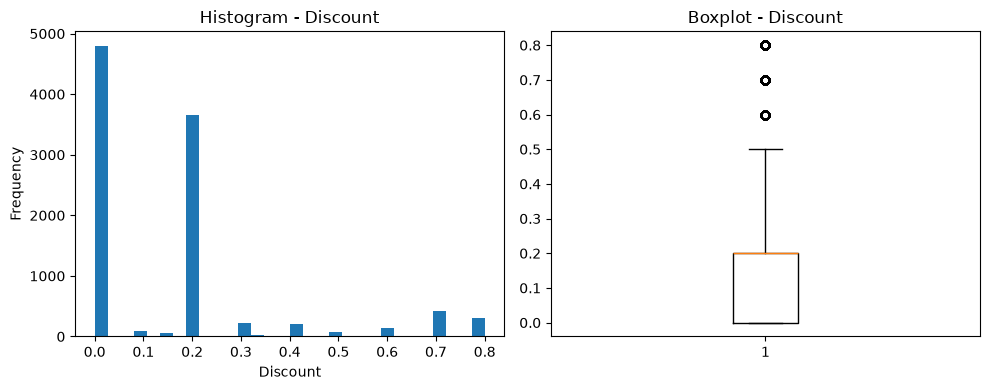

C:\Users\user\AppData\Local\Temp\ipykernel_5052\1555213245.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(d[col].dropna(), vert=True)


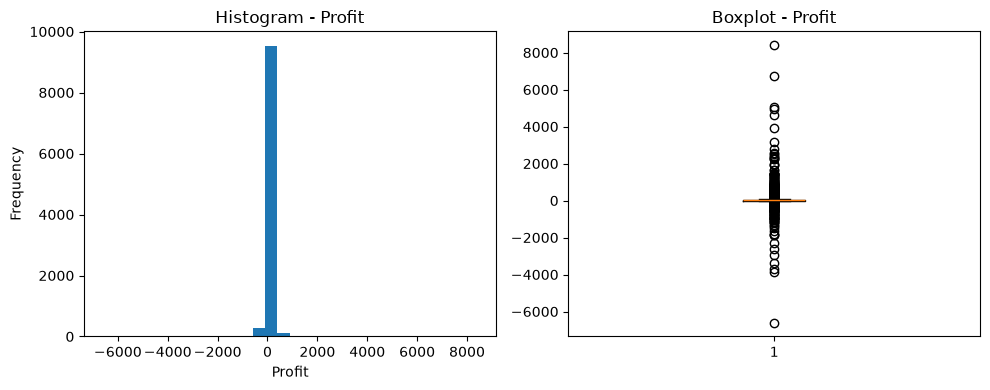

In [22]:
import matplotlib.pyplot as plt

numeric_cols = d.select_dtypes(include='number').columns

for col in numeric_cols:

    plt.figure(figsize=(10,4))

    # Histogram
    plt.subplot(1,2,1)
    plt.hist(d[col].dropna(), bins=30)
    plt.title(f"Histogram - {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    # Boxplot
    plt.subplot(1,2,2)
    plt.boxplot(d[col].dropna(), vert=True)
    plt.title(f"Boxplot - {col}")

    plt.tight_layout()
    plt.show()

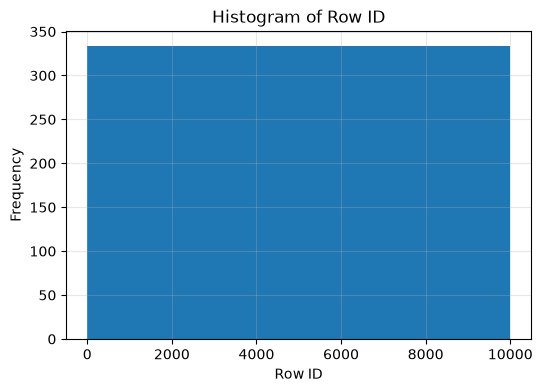

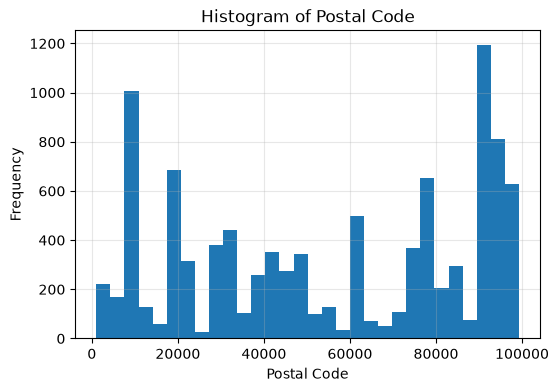

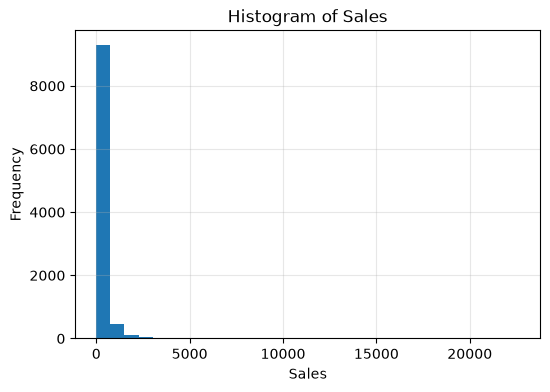

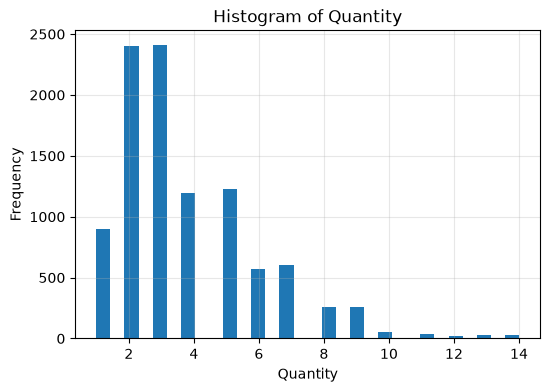

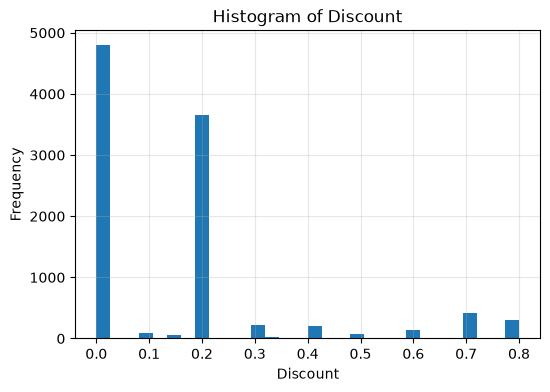

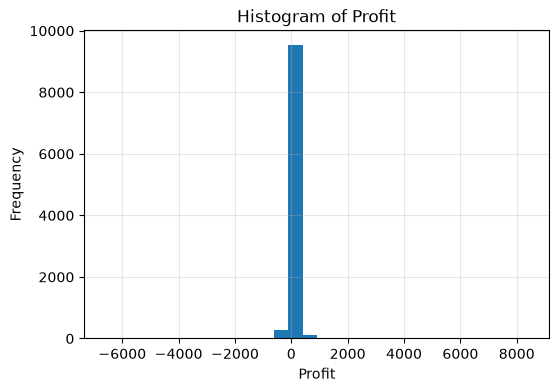

In [20]:
import matplotlib.pyplot as plt

# Select numeric columns
numeric_cols = d.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(d[col].dropna(), bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

In [23]:
Q1 = d["Sales"].quantile(0.25)
Q3 = d["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

d["Sales"] = d["Sales"].clip(lower, upper)

In [24]:
Q1 = d["Profit"].quantile(0.25)
Q3 = d["Profit"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

d["Profit"] = d["Profit"].clip(lower, upper)

In [25]:
print(d["Discount"].describe())
print(d["Discount"].unique())

count    9994.000000
mean        0.156203
std         0.206452
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: Discount, dtype: float64
[0.   0.45 0.2  0.8  0.3  0.5  0.7  0.6  0.32 0.1  0.4  0.15]


In [26]:
print(d["Discount"].min())
print(d["Discount"].max())

0.0
0.8


In [27]:
invalid_discount = d[
    (d["Discount"] < 0) |
    (d["Discount"] > 0.8)
]

print(invalid_discount)

Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit]
Index: []

[0 rows x 21 columns]


In [28]:
print(d["Quantity"].describe())

count    9994.000000
mean        3.789574
std         2.225110
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: Quantity, dtype: float64


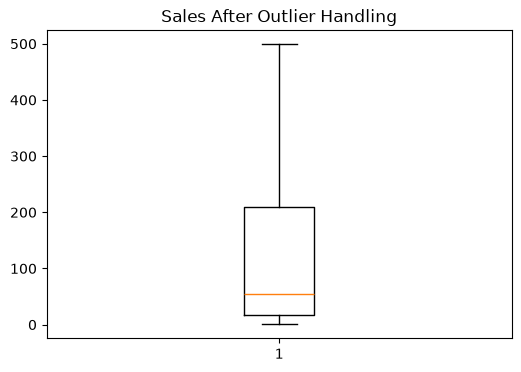

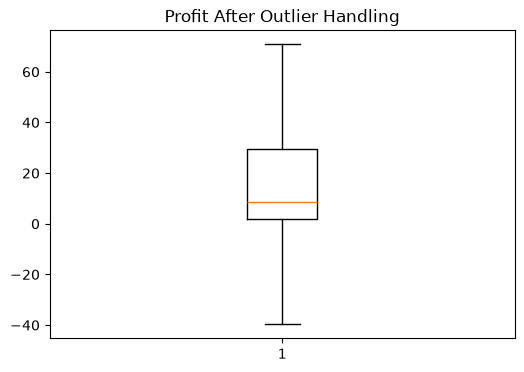

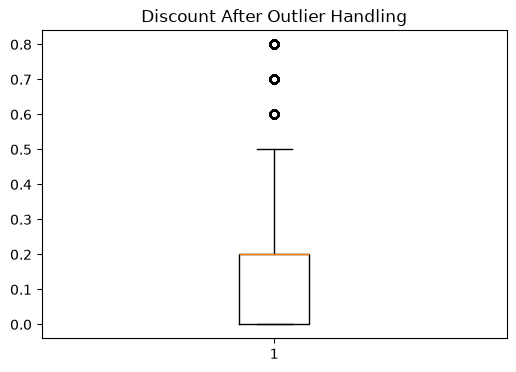

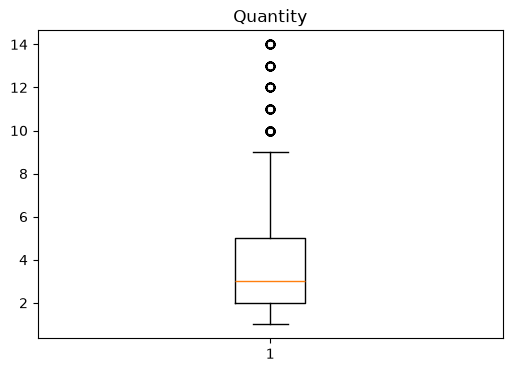

In [29]:
plt.figure(figsize=(6,4))
plt.boxplot(d["Sales"])
plt.title("Sales After Outlier Handling")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(d["Profit"])
plt.title("Profit After Outlier Handling")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(d["Discount"])
plt.title("Discount After Outlier Handling")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(d["Quantity"])
plt.title("Quantity")
plt.show()

In [30]:
Q1 = d["Sales"].quantile(0.25)
Q3 = d["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((d["Sales"] < lower) | (d["Sales"] > upper)).sum()

print("Sales Outliers:", outliers)

Sales Outliers: 0


In [ ]:
Q1 = d["Sales"].quantile(0.25)
Q3 = d["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((d["Sales"] < lower) | (d["Sales"] > upper)).sum()

print("Sales Outliers After Handling:", outliers)

Sales Outliers After Handling: 0


In [32]:
d["Order Date"] = pd.to_datetime(d["Order Date"])
d["Ship Date"] = pd.to_datetime(d["Ship Date"])

In [34]:
d.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [ ]:
# checking for incosistent categories
for col in d.select_dtypes(include='object').columns:
    print(col)
    print(d[col].value_counts().head())

Order ID
Order ID
CA-2017-100111    14
CA-2017-157987    12
CA-2016-165330    11
US-2016-108504    11
US-2015-126977    10
Name: count, dtype: int64
Ship Mode
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64
Customer ID
Customer ID
WB-21850    37
MA-17560    34
JL-15835    34
PP-18955    34
CK-12205    32
Name: count, dtype: int64
Customer Name
Customer Name
William Brown          37
Matt Abelman           34
John Lee               34
Paul Prost             34
Chloris Kastensmidt    32
Name: count, dtype: int64
Segment
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64
Country
Country
United States    9994
Name: count, dtype: int64
City
City
New York City    915
Los Angeles      747
Philadelphia     537
San Francisco    510
Seattle          428
Name: count, dtype: int64
State
State
California      2001
New York        1128
Texas            985
Pennsylvania     587
W

In [36]:
d.info()
d.describe()
d.isnull().sum()
d.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

np.int64(0)

In [37]:
d.to_csv("Sample-superstore-cleaned.csv", index=False)